# Taxi Fare Analysis Notebook

This notebook is designed to answer business questions about ride fares using the right chart for each question.

For each question, we will do the following:
- choose the most suitable plot
- explain why it is appropriate
- clean the data if needed
- write the code
- interpret the result

The dataset contains variables such as `fare_amount`, `passenger_count`, `distance`, `hour`, `Car Condition`, `Weather`, and `Traffic Condition`.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

try:
    df = pd.read_csv('final_internship_data.csv')
except FileNotFoundError:
    df = pd.read_csv(r'/content/final_internship_data.csv')

print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nSample rows:')
print(df.head(3).to_string(index=False))

Dataset shape: (58365, 26)

Columns:
['User ID', 'User Name', 'Driver Name', 'Car Condition', 'Weather', 'Traffic Condition', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance', 'bearing']

Sample rows:
 User ID       User Name      Driver Name Car Condition Weather Traffic Condition                          key  fare_amount     pickup_datetime  pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  hour  day  month  weekday  year  jfk_dist  ewr_dist  lga_dist  sol_dist  nyc_dist  distance   bearing
KHVrEVlD  Kimberly Adams       Amy Butler     Very Good   windy Congested Traffic  2009-06-15 17:26:21.0000001          4.5 2009-06-15 17:26:21         -1.288826         0.710721          -1.288779          0.710563                1    17   15      6        

In [12]:
# Cleaning notes
# 1. Drop rows with missing values in variables needed for analysis.
# 2. Remove invalid records such as zero or negative fare/distance values.
# 3. Convert hour to integer for grouped time analysis.
# 4. Keep a copy of the cleaned data for reuse.

clean_df = df.copy()
required_cols = ['fare_amount', 'passenger_count', 'distance', 'hour', 'Car Condition', 'Weather', 'Traffic Condition']
clean_df = clean_df.dropna(subset=required_cols)
clean_df = clean_df[(clean_df['fare_amount'] > 0) & (clean_df['distance'] > 0)].copy()
clean_df['hour'] = clean_df['hour'].astype(int)

print('Cleaned data shape:', clean_df.shape)
print(clean_df[['fare_amount', 'distance', 'passenger_count', 'hour']].describe().round(2).to_string())


Cleaned data shape: (56667, 26)
       fare_amount  distance  passenger_count     hour
count     56667.00  56667.00         56667.00  56667.0
mean         11.35     18.17             1.67     13.5
std           9.54    349.84             1.30      6.5
min           0.01      0.00             0.00      0.0
25%           6.00      1.29             1.00      9.0
50%           8.50      2.19             1.00     14.0
75%          12.50      3.98             2.00     19.0
max         200.00   8670.15             6.00     23.0


## Q1) Is higher passenger count associated with higher fare?

### Plot choice
Scatter plot is the most appropriate choice because both variables are numerical, and we want to see whether the points form a pattern or trend.

### Why this plot
- `passenger_count` is numerical
- `fare_amount` is numerical
- A scatter plot shows whether higher passenger counts tend to coincide with higher fares
- It helps detect weak, strong, or no linear relationship


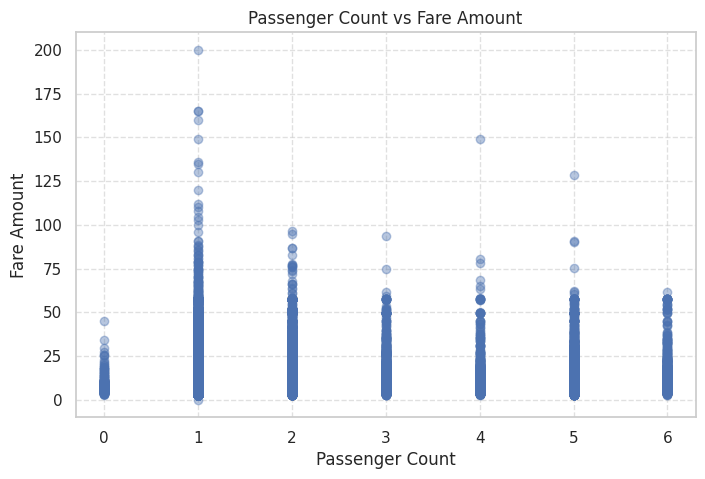

Correlation between passenger_count and fare_amount:
0.017701453618488006


In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df['passenger_count'], clean_df['fare_amount'], alpha=0.4)
plt.title('Passenger Count vs Fare Amount')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('Correlation between passenger_count and fare_amount:')
print(clean_df['passenger_count'].corr(clean_df['fare_amount']))


### Interpretation
If the points are spread without a clear trend, then passenger count is not a strong predictor of fare. If there is a visible upward trend, the fare tends to rise as passenger count increases.

## Q2) Does car condition influence the fare amount?

### Plot choice
Boxplot is the best option because the predictor is categorical (`Car Condition`) and the response is numerical (`fare_amount`).

### Why this plot
- We compare the distribution of fares across several categories
- A boxplot shows median, spread, and outliers
- It is better than a bar plot for showing variability within each category


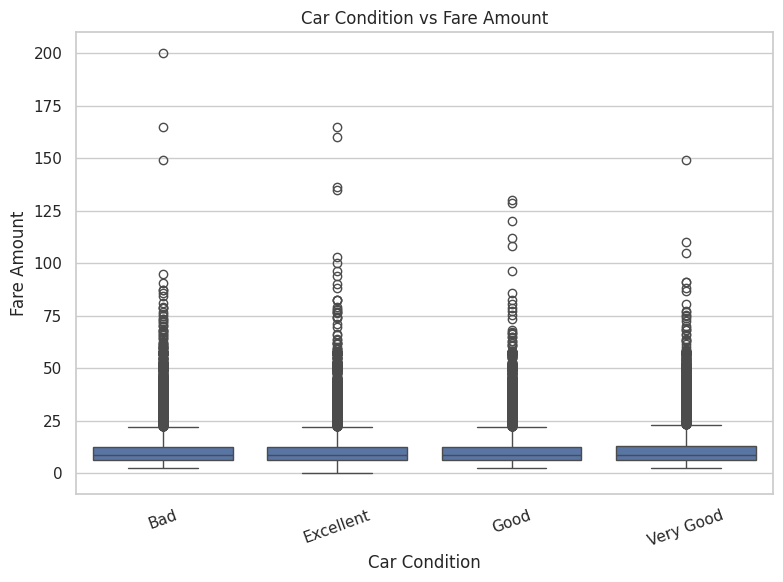

                mean  median   min    max
Car Condition                            
Bad            11.51     8.5  2.50  200.0
Excellent      11.20     8.5  0.01  165.0
Good           11.28     8.5  2.50  130.0
Very Good      11.38     8.5  2.50  149.0


In [14]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=clean_df, x='Car Condition', y='fare_amount', order=sorted(clean_df['Car Condition'].unique()))
plt.title('Car Condition vs Fare Amount')
plt.xlabel('Car Condition')
plt.ylabel('Fare Amount')
plt.xticks(rotation=20)
plt.show()

print(clean_df.groupby('Car Condition')['fare_amount'].agg(['mean', 'median', 'min', 'max']).round(2))


### Interpretation
If one car condition category has a noticeably higher median fare, that suggests the condition is associated with fare differences. The boxplot also shows whether the difference is consistent or driven by outliers.

## Q3) At what hour of the day are fares typically highest?

### Plot choice
Line plot is appropriate because `hour` is numerical and we want to examine how the average fare changes over the 24-hour cycle.

### Why this plot
- The variable is ordered over time
- A line plot highlights daily patterns and peaks
- It shows whether fares rise during rush hours or late-night periods


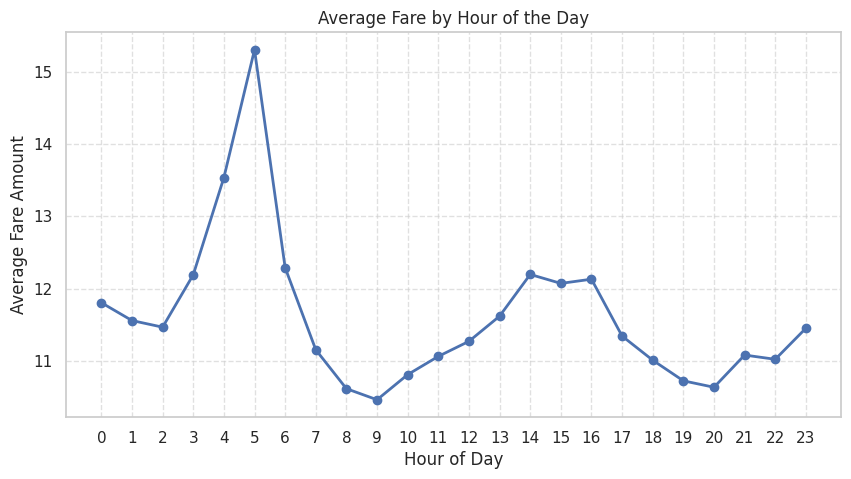

 hour  fare_amount
    0        11.81
    1        11.56
    2        11.47
    3        12.19
    4        13.54
    5        15.30
    6        12.29
    7        11.16
    8        10.62
    9        10.47

Peak hour:
hour            5.000000
fare_amount    15.303148
Name: 5, dtype: float64


In [15]:
hourly_fare = clean_df.groupby('hour', as_index=False)['fare_amount'].mean().sort_values('hour')

plt.figure(figsize=(10, 5))
plt.plot(hourly_fare['hour'], hourly_fare['fare_amount'], marker='o', linewidth=2)
plt.title('Average Fare by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Amount')
plt.xticks(range(0, 24, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(hourly_fare.head(10).round(2).to_string(index=False))
print('\nPeak hour:')
print(hourly_fare.loc[hourly_fare['fare_amount'].idxmax()])

### Interpretation
A peak in the line plot indicates the time when fares are highest on average. This is useful for identifying rush hour or time periods with increased demand and pricing pressure.

## Q4) Does traffic condition affect the trip fare?

### Plot choice
Boxplot is the most informative choice because `Traffic Condition` is categorical and `fare_amount` is numerical.

### Why this plot
- It compares fare distributions across traffic categories
- We can see median fare differences and variability
- It helps determine whether heavy traffic is linked with more expensive rides


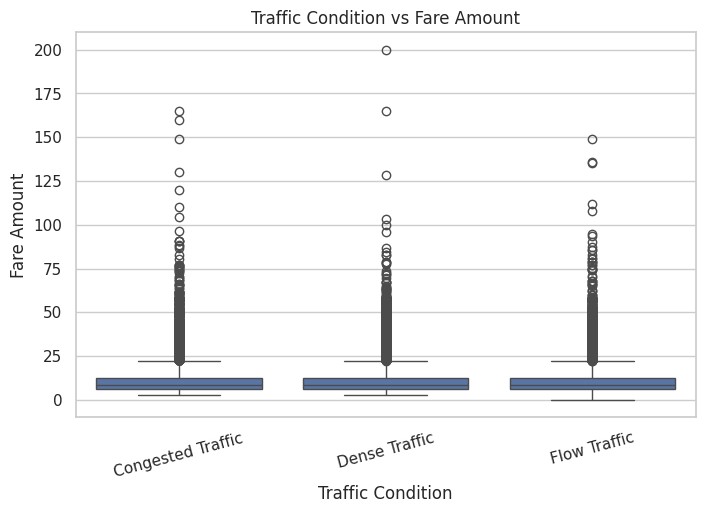

                    mean  median
Traffic Condition               
Congested Traffic  11.39     8.5
Dense Traffic      11.33     8.5
Flow Traffic       11.31     8.5


In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_df, x='Traffic Condition', y='fare_amount', order=sorted(clean_df['Traffic Condition'].unique()))
plt.title('Traffic Condition vs Fare Amount')
plt.xlabel('Traffic Condition')
plt.ylabel('Fare Amount')
plt.xticks(rotation=15)
plt.show()

print(clean_df.groupby('Traffic Condition')['fare_amount'].agg(['mean', 'median']).round(2))


### Interpretation
If Congested Traffic shows a noticeably higher median fare than Flow Traffic, then traffic condition influences trip cost. This suggests that time delays or demand surges may raise the fare.

## Q5) Is trip distance the strongest predictor of fare amount?

### Plot choice
Scatter plot is the correct choice because both variables are numerical and we want to inspect the relationship shape.

### Why this plot
- Distance and fare are continuous variables
- A scatter plot reveals whether the relationship is linear, clustered, or weak
- It helps check whether fare increases steadily as distance grows


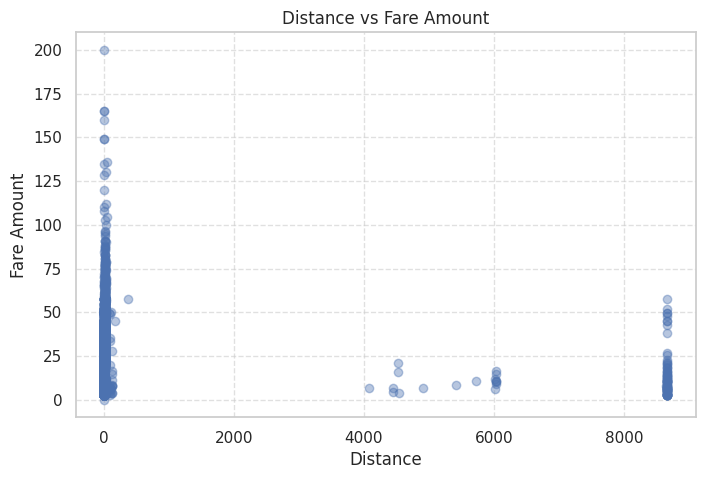

Correlation between distance and fare_amount:
0.017545729196008258


In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df['distance'], clean_df['fare_amount'], alpha=0.4)
plt.title('Distance vs Fare Amount')
plt.xlabel('Distance')
plt.ylabel('Fare Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('Correlation between distance and fare_amount:')
print(clean_df['distance'].corr(clean_df['fare_amount']))


### Interpretation
A strong positive trend usually indicates that distance is a major driver of fare. If the points fan out broadly, then other variables such as traffic or airport access may also matter.

## Q6) At what time of day are ride requests most frequent?

### Plot choice
A count plot or bar chart is ideal because the question asks for frequencies, not prices.

### Why this plot
- `hour` is a numerical variable, but the goal is frequency of requests by hour
- We need counts per hour, not average fare
- A bar plot makes peak demand periods easy to spot


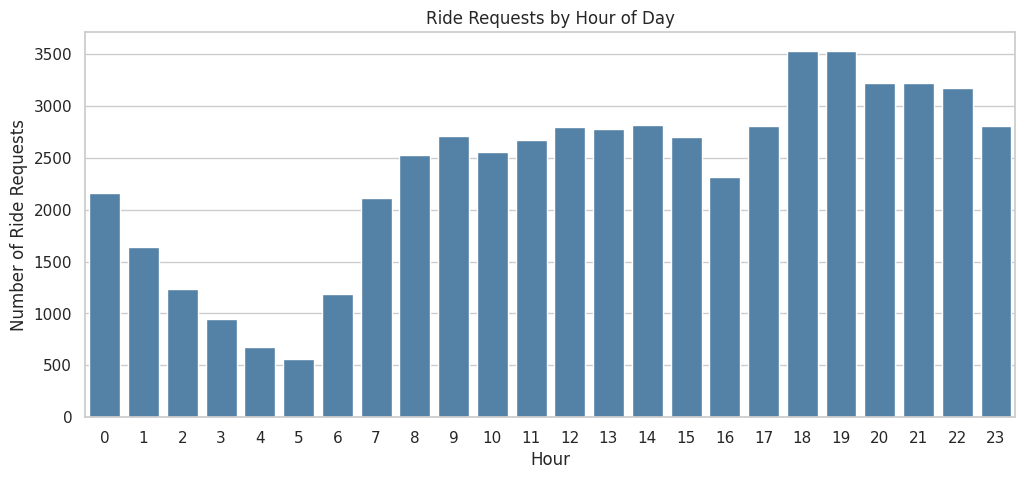

hour
0    2161
1    1643
2    1237
3     948
4     680
5     559
6    1190
7    2109
8    2522
9    2710

Peak hour for demand:
19 3532


In [19]:
hour_counts = clean_df['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=hour_counts.index, y=hour_counts.values, color='steelblue')
plt.title('Ride Requests by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Ride Requests')
plt.xticks(rotation=0)
plt.show()

print(hour_counts.head(10).to_string())
print('\nPeak hour for demand:')
print(hour_counts.idxmax(), hour_counts.max())


### Interpretation
This chart identifies the hours with the highest number of ride requests. This is distinct from Q3, which focuses on fare averages by hour rather than demand volume.

## Q7) Does weather condition influence the average trip distance?

### Plot choice
Boxplot or bar chart can work, but boxplot is usually better because `Weather` is categorical and `distance` is numerical.

### Why this plot
- We want to compare distance distributions by weather category
- Boxplots show central tendency and variability
- They help identify whether bad weather leads to shorter or longer trips


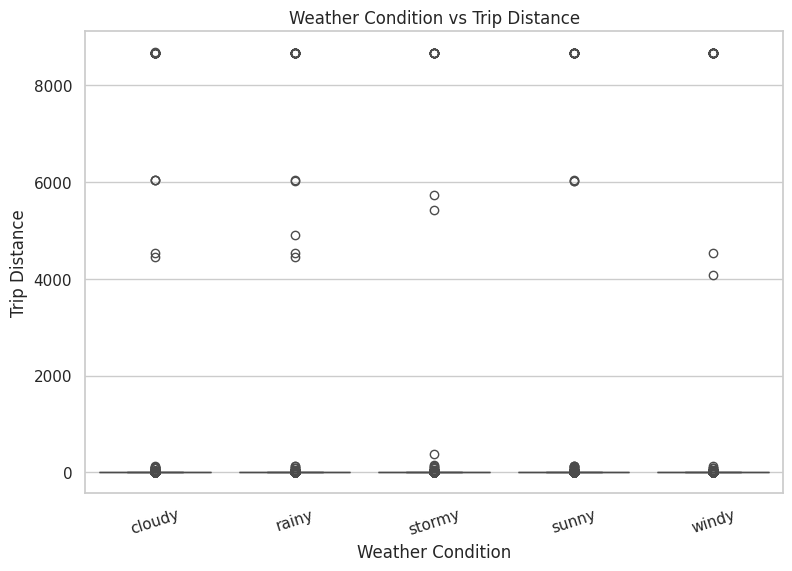

          mean  median     std
Weather                       
cloudy   22.81    2.19  399.80
rainy    20.29    2.23  371.25
stormy   12.03    2.15  267.08
sunny    17.14    2.18  338.31
windy    18.66    2.19  359.32


In [20]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=clean_df, x='Weather', y='distance', order=sorted(clean_df['Weather'].unique()))
plt.title('Weather Condition vs Trip Distance')
plt.xlabel('Weather Condition')
plt.ylabel('Trip Distance')
plt.xticks(rotation=18)
plt.show()

print(clean_df.groupby('Weather')['distance'].agg(['mean', 'median', 'std']).round(2))


### Interpretation
If one weather category has a notably different median distance, then the weather may influence trip length. For example, rainy or stormy conditions may lead to shorter routes or higher caution.

## Q8) Are rides that start closer to airports generally more expensive?

### Plot choice
Scatter plot is the best choice because we are examining the relationship between two numerical variables: airport distance and fare amount.

### Why this plot
- `jfk_dist` or another airport distance variable is numerical
- `fare_amount` is numerical
- The plot shows whether shorter airport distances are linked with higher fares


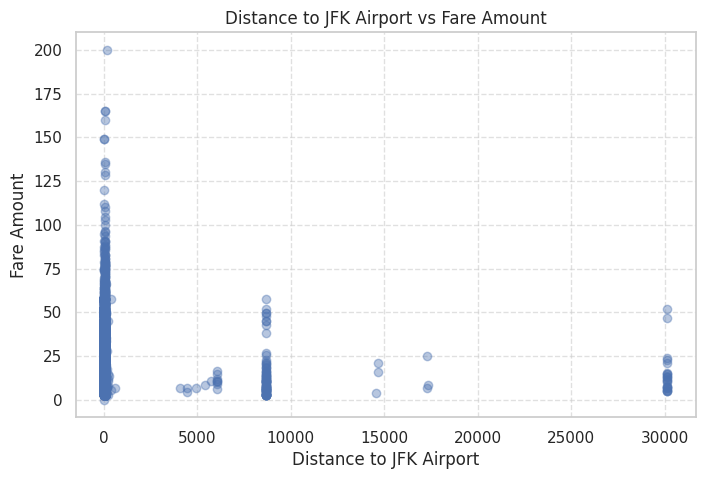

Correlation between jfk_dist and fare_amount:
0.007837594762154003


In [21]:
# Example: distance to JFK airport
plt.figure(figsize=(8, 5))
plt.scatter(clean_df['jfk_dist'], clean_df['fare_amount'], alpha=0.4)
plt.title('Distance to JFK Airport vs Fare Amount')
plt.xlabel('Distance to JFK Airport')
plt.ylabel('Fare Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('Correlation between jfk_dist and fare_amount:')
print(clean_df['jfk_dist'].corr(clean_df['fare_amount']))


### Interpretation
A negative trend would suggest that rides starting closer to the airport tend to be more expensive, while a weak or random pattern would indicate little relationship.

## Extra Questions for Deeper Understanding

The following questions extend the analysis beyond the basic set and can help uncover stronger business insights.

1. Does trip distance explain more of the fare variation than traffic condition?
2. Are fares higher during weekends than weekdays?
3. Does weather affect the number of ride requests as well as the fare amount?
4. Which airport distance variable (`jfk_dist`, `ewr_dist`, `lga_dist`) is the strongest predictor of price?
5. Are there peak periods where both demand and fare are simultaneously high?

### Final note
In exploratory data analysis, the correct chart depends on the variable types and the question being asked. Numerical vs numerical questions usually use scatter plots; numerical vs categorical questions usually use boxplots or bar charts; frequency questions use count plots or bar charts; and time-series-like questions often use line plots.


In [24]:
# Extra example 1: weekend vs weekday
clean_df['is_weekend'] = clean_df['weekday'].isin([5, 6]).astype(int)
weekend_summary = clean_df.groupby('is_weekend')['fare_amount'].agg(['mean', 'median']).round(2)
print('Weekend effect on fare:')
print(weekend_summary)

# Extra example 2: weather effect on demand
weather_counts = clean_df['Weather'].value_counts()
print('\nRide counts by weather:')
print(weather_counts)

# Extra example 3: distance-to-fare correlation across airport metrics
for col in ['jfk_dist', 'ewr_dist', 'lga_dist']:
    corr = clean_df[col].corr(clean_df['fare_amount'])
    print(f'\nCorrelation for {col}: {corr:.4f}')

Weekend effect on fare:
             mean  median
is_weekend               
0           11.36     8.5
1           11.31     8.5

Ride counts by weather:
Weather
sunny     11426
stormy    11381
rainy     11314
windy     11310
cloudy    11236
Name: count, dtype: int64

Correlation for jfk_dist: 0.0078

Correlation for ewr_dist: 0.0137

Correlation for lga_dist: 0.0113
